중요도가 낮은 변수 아예 없애버림


중요한변수 몇개만 설명하고 싶을때

요 작업을 할 때alpha 바꿔보면서 봐라~

0.01 일떄 5회, 0.1일때 5회....이렇게 해서 25번

나중에 estimator.predict(x_Test) 하면
최적화된 파라미터로 스케일링하고 바로 모델 적합

pipeline 사용법
훈련 보델별 class 이름 + 하이퍼 파라미터가 무엇인지 파악




# [LAB 07] 지도학습 > 예측 >선형>규제적용 > Lasso

## #01. 라쏘 회귀 개요
- 선형회귀에 벌점을 추가해서 중요하지 않은 변수를 자동으로 제거하는 방법
  
### [1] 일반 선형회귀의 문제점
- 변수 수 많음
- 변수 중 일부만 실제로 중요
- 해석이 복잡해짐
> 라쏘 회귀는 변수를 줄여줌


### [2] 핵심 아이디어
- 계수 크기에 벌점 부과
- 중요하지 않은 변수의 계수를 0으로 만들어 줌
- 결과적으로 변수 선택 효과 발생


### [3] 릿지와의 차이점
|구분|라쏘|릿지|
|-|-|-|
|규제방식|L1|L2|
|계수0가능|O|X|
|변수 선택 | 강함 | 없음|
|모델 성격|희소|안정|


### [4] 언제 쓰면 좋은가?
- 변수 수 많을 때
- 중요한변수는 소수일때
- 해석이 중요할 때
- 모델 단순화가 필요할 때

## #02.준비작업
### [1] 패키지 참조

In [1]:
from hossam import *
from pandas import DataFrame, read_excel
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import statsmodels as sm


#데이터 표준화 모듈
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve



#성능 평가 지표 모듈
from sklearn.metrics import(
  r2_score,
  mean_absolute_error,
  mean_squared_error,
  mean_absolute_percentage_error
)

#라쏘 회귀
from sklearn.linear_model import Lasso

### [2] 데이터 가져오기

In [2]:
origin=load_data('fish_processed')
origin.head()

농어의 길이,높이,두께,무게를 조사한 데이터의 전처리 버전


,길이,높이,두께,무게
0,8.4,2.11,1.41,1.931521
1,13.7,3.53,2.00,3.496508
2,15.0,3.82,2.43,3.713572
3,16.2,4.59,2.63,3.960813
4,17.4,4.59,2.94,4.262680


### [3] 훈련,검증 데이터 분리

In [3]:
df = origin

yname = '무게'
x=df.drop(columns=[yname])
y=df[yname]


x_train,x_test,y_train,y_test = train_test_split(
  x,y,test_size=0.25,random_state=52
)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((42, 3), (14, 3), (42,), (14,))

## #02 라쏘 회귀 모형 적합

### [1] 주요 하이퍼 파라미터
라쏘 회귀 튜닝은 alpha 하나로 규제 강도 + 변수 선택 정도를 조절하는 문제

|하이퍼 파라미터|의미|기본값|역할|값 설정 가이드|
|-|-|-|-|
|alpha|규제 강도 람다 | 1.0 | 계수 절댓값에 벌점 부과 -> 변수 선택 발생 | 작으면 많은 변수를 유지하고, 크면 계수가 0에 가까워짐|
|random_state|난수 시드|None|selection='random' 일 떄 재현성 | 실험 재현 시 설정|




#### 핵심 정리
- 가장 중요한 파라미터는 alpha
- alpha 는 과적합 억제 역할 + 변수 선택 동시에 결정
- 나머지 파라미터는 수렴,재현성 보조용
- 실무에서는 alpha 만 GridSearchCV 로 튜닝하는 경우가 대부분

### [2] 모델 적합
- 라쏘 모델도 릿지 모델과 마찬가지로 데이터의 스케일에 민감하기 떄문에 반드시 스케일링을 적용해야함

- 실습에서 사용하는 데이터셋은 fish 데이터셋에 로그 > 스케일링이 적용된 결과에 이어서 진행하는 것이므로 이 예제에서는 직접적으로 스케일링을 처리하지는 않음

In [4]:
%%time

#Lasso 모델 정의 (n_jobs 없음)

pipe = Pipeline([('scaler', StandardScaler()) , ('model',Lasso(random_state=52))])


#탐색할 하이퍼파라미터 그리드 설정
param_grid = {'model__alpha':[0.01,0.1,1,10,100]}

#그리드 서치 객체 생성
gs = GridSearchCV(estimator=pipe,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)


gs.fit(x_train,y_train)

estimator=gs.best_estimator_

estimator

CPU times: total: 78.1 ms
Wall time: 2.77 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


## #04. 성능 평가
### [1] 성능 평가 지표
- 앞 단원의 코드 재사용

In [5]:
y_pred = estimator.predict(x_test)


result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["성능지표"],
)

result_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
성능지표,0.961509,0.171297,0.044678,0.211371,0.03111,0.428971


### [2] 과적합 여부 확인

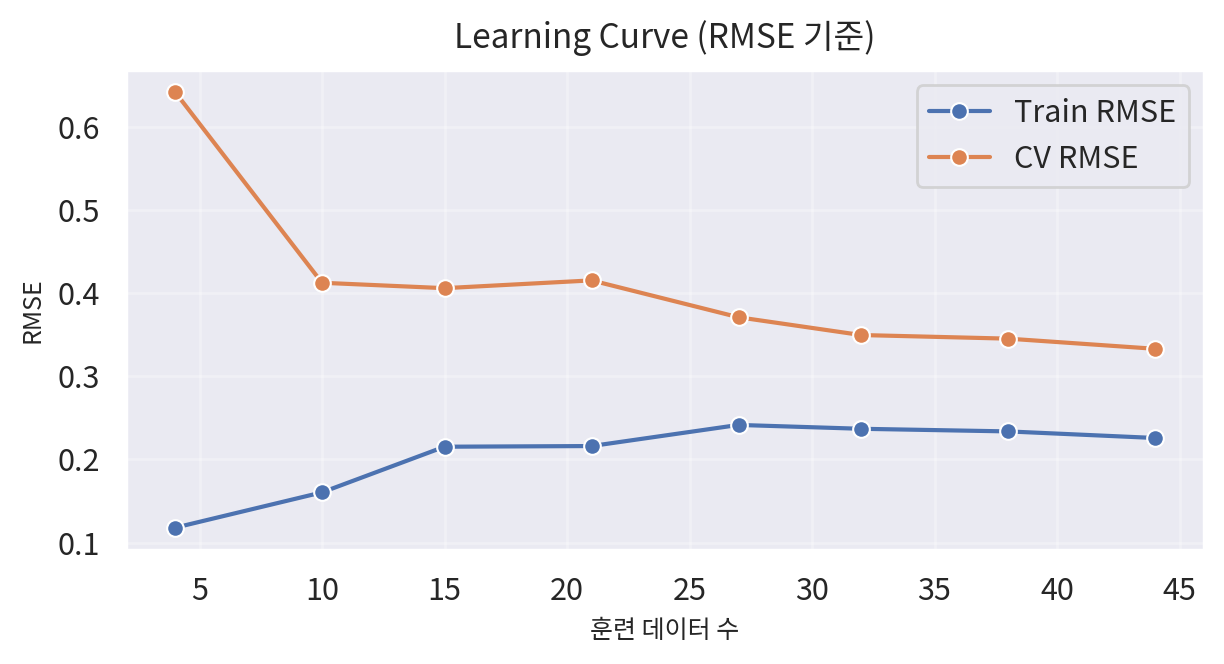

,지표,값
0,Train RMSE,0.225789
1,CV RMSE 평균,0.332969
2,CV RMSE 표준편차,0.230784
3,Train/CV 비율,0.678108
4,CV 변동성 비율,0.693109
5,판정 결과,⚠️과대적합 (variance 큼)


In [6]:
# ==========================
# # 과적합 여부 확인
# ==========================

# 반드시 원본 데이터 적용
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=52,
    n_jobs=-1,
)

# neg RMSE -> RMSE
train_rmse = -train_scores
cv_rmse = -cv_scores

# 평균 / 표준편차
train_mean = train_rmse.mean(axis=1)
cv_mean = cv_rmse.mean(axis=1)
cv_std = cv_rmse.std(axis=1)

# 마지막 지점 기준 경향 판정
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train / final_cv
var_ratio = final_std / final_cv

# --------------------------
# # 과적합 기준선 (some_threshold)
# --------------------------

# 기준모형 RMSE (평균예측)
y_mean = y.mean()
rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

# 분산 기반
std_y = y.std()

# 최소 설명력(R^2) 기반
min_r2 = 0.10
rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

# 최종 threshold (가장 관대한 기준)
# -> 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도 성능은 내야 한다는 기준을 설정하는 것
some_threshold = min(rmse_naive, std_y, rmse_r2)

# --------------------------
# # 판정 로직
# --------------------------
if gap_ratio >= 0.95 and final_cv > some_threshold:
    status = "⚠️과소적합 (bias 큼)"
elif gap_ratio <= 0.8:
    status = "⚠️과대적합 (variance 큼)"
elif gap_ratio <= 0.95 and var_ratio <= 0.10:
    status = "✅일반화 양호"
elif var_ratio > 0.15:
    status = "⚠️데이터 부족 / 분산 큼"
else:
    status = "⚠️판단 유보"

# ==========================
# # 시각화 (Learning Curve)
# ==========================
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Train RMSE",
    ax=ax,
)
sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    label="CV RMSE",
    ax=ax,
)

ax.set_title("Learning Curve (RMSE 기준)", fontsize=12, pad=8)
ax.set_xlabel("훈련 데이터 수", fontsize=9)
ax.set_ylabel("RMSE", fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

# ==========================
# # 정량 결과 표
# ==========================
result_df = DataFrame(
    {
        "지표": [
            "Train RMSE",
            "CV RMSE 평균",
            "CV RMSE 표준편차",
            "Train/CV 비율",
            "CV 변동성 비율",
            "판정 결과",
        ],
        "값": [
            final_train,
            final_cv,
            final_std,
            gap_ratio,
            var_ratio,
            status,
        ],
    }
)

result_df


### [3] 학습 곡선

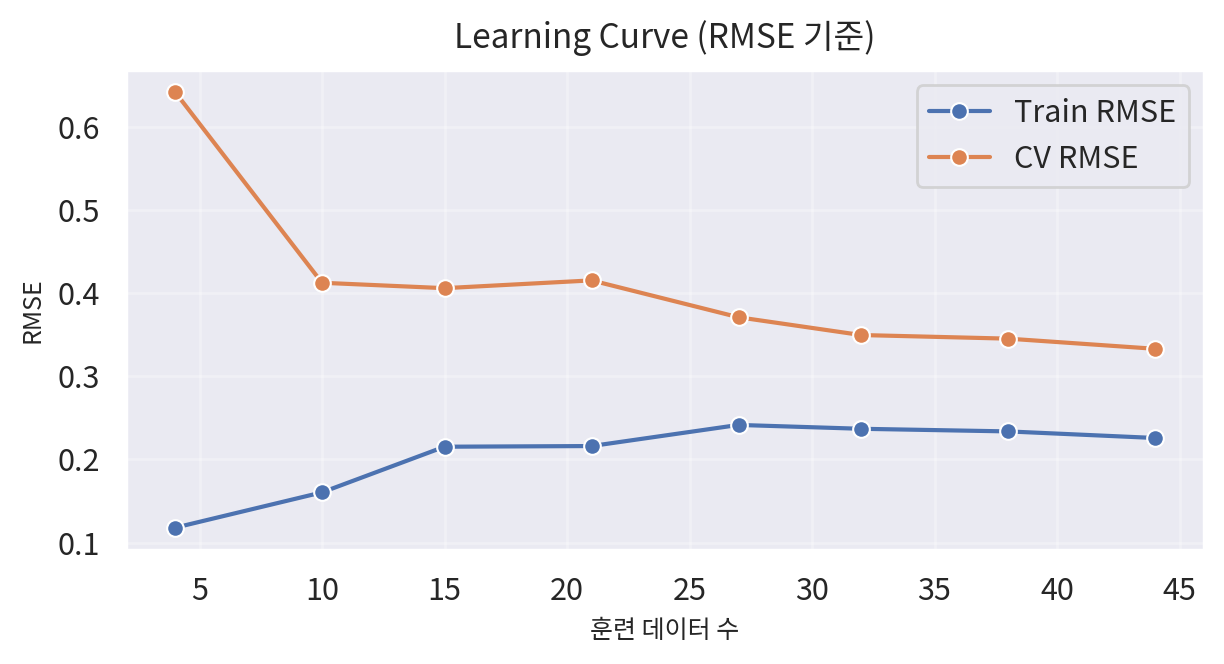

,지표,값
0,Train RMSE,0.225789
1,CV RMSE 평균,0.332969
2,CV RMSE 표준편차,0.230784
3,Train/CV 비율,0.678108
4,CV 변동성 비율,0.693109
5,판정 결과,⚠️과대적합 (variance 큼)


In [7]:
# ==========================
# # 과적합 여부 확인
# ==========================

# 반드시 원본 데이터 적용
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=52,
    n_jobs=-1,
)

# neg RMSE -> RMSE
train_rmse = -train_scores
cv_rmse = -cv_scores

# 평균 / 표준편차
train_mean = train_rmse.mean(axis=1)
cv_mean = cv_rmse.mean(axis=1)
cv_std = cv_rmse.std(axis=1)

# 마지막 지점 기준 경향 판정
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train / final_cv
var_ratio = final_std / final_cv

# --------------------------
# # 과적합 기준선 (some_threshold)
# --------------------------

# 기준모형 RMSE (평균예측)
y_mean = y.mean()
rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

# 분산 기반
std_y = y.std()

# 최소 설명력(R^2) 기반
min_r2 = 0.10
rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

# 최종 threshold (가장 관대한 기준)
# -> 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도 성능은 내야 한다는 기준을 설정하는 것
some_threshold = min(rmse_naive, std_y, rmse_r2)

# --------------------------
# # 판정 로직
# --------------------------
if gap_ratio >= 0.95 and final_cv > some_threshold:
    status = "⚠️과소적합 (bias 큼)"
elif gap_ratio <= 0.8:
    status = "⚠️과대적합 (variance 큼)"
elif gap_ratio <= 0.95 and var_ratio <= 0.10:
    status = "✅일반화 양호"
elif var_ratio > 0.15:
    status = "⚠️데이터 부족 / 분산 큼"
else:
    status = "⚠️판단 유보"

# ==========================
# # 시각화 (Learning Curve)
# ==========================
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Train RMSE",
    ax=ax,
)
sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    label="CV RMSE",
    ax=ax,
)

ax.set_title("Learning Curve (RMSE 기준)", fontsize=12, pad=8)
ax.set_xlabel("훈련 데이터 수", fontsize=9)
ax.set_ylabel("RMSE", fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

# ==========================
# # 정량 결과 표
# ==========================
result_df = DataFrame(
    {
        "지표": [
            "Train RMSE",
            "CV RMSE 평균",
            "CV RMSE 표준편차",
            "Train/CV 비율",
            "CV 변동성 비율",
            "판정 결과",
        ],
        "값": [
            final_train,
            final_cv,
            final_std,
            gap_ratio,
            var_ratio,
            status,
        ],
    }
)

result_df
